# Spam Detection Project

Loading the Dataset:

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])
# Display the first few rows
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Checking Basic Info (Columns, Data Types)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Checking the Missing Values

In [3]:
df.isnull().sum()

label      0
message    0
dtype: int64

Checking  the Distribution of Ham (Legitimate) vs. Spam 

In [4]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

Visualizing Spam vs. Ham Distribution

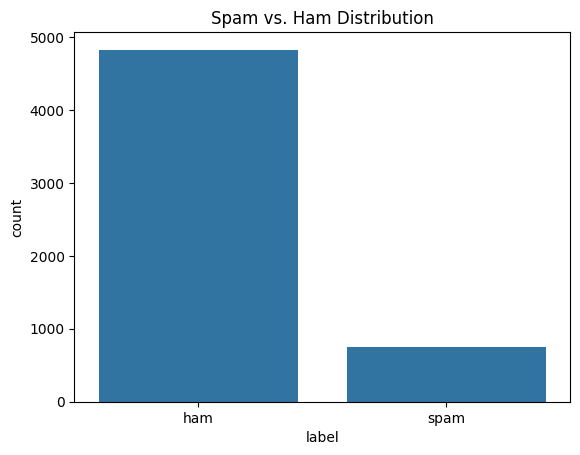

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df['label'])
plt.title("Spam vs. Ham Distribution")
plt.show()

Check Sample Messages

In [6]:
# View some spam messages
df[df['label'] == 'spam'].head()

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."


In [7]:
# View some ham (legitimate) messages
df[df['label'] == 'ham'].head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...


Let's clean the text data to prepare it for Machine Learning.

In [8]:
import re                      # regular expression module used for pattern matching and text cleaning
import string                  # provides string-related constants and functions 
import nltk                    # natural language processing toolkit for tokenization, stemming, stopwords etc.
from nltk.corpus import stopwords  
from nltk.stem import PorterStemmer  

# Contains a list of common stopwords (e.g., "is," "the," "and") which are typically removed because they add little meaning in text analysis.
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Text Pre-processing (Cleaning Text)

In [ ]:
# Implementing stemming, a process that reduces words to their root form
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))  
print(stop_words)   # Get stopwords list

{"aren't", 'their', "you've", 'any', "couldn't", 'up', "it's", 'themselves', 'those', 'what', 'some', "weren't", 'ma', 'are', 'do', 'will', 'after', 'didn', 'hers', 'which', 'not', 'each', 'against', 'them', 'theirs', 'be', 'shan', "i'll", 'too', "haven't", 'have', 'ourselves', 'out', "doesn't", 'herself', "should've", 'o', 'whom', "mustn't", 'mustn', 've', 'y', 'were', 'all', 'yourselves', 'there', 'd', "we've", 'below', 'while', 'was', 'won', 'you', 'because', 'that', 'over', 'its', 'this', 'mightn', 'before', 'weren', 'so', "they'd", "won't", 'such', 'she', 'does', 'doesn', 'if', 'own', 'it', 'needn', 'more', 'between', "she'll", 'these', 'here', 'him', 'when', 'doing', "they've", 'where', 'once', "she'd", 're', 'from', "he's", 'myself', 'only', 'on', 'll', 'then', "don't", 'down', 'yours', "he'll", 'off', 'the', "he'd", "that'll", 'nor', "she's", 'we', "isn't", "didn't", 'few', 'as', 'through', 'very', 'is', 'now', "hadn't", 'about', 'in', 'isn', 'had', "you'll", "you're", 'again',

Apply Cleaning Function to Dataset

In [ ]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters, punctuation, and numbers
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Apply stemming
    words = [stemmer.stem(word) for word in words]
    
    # Join words back into a single string
    return ' '.join(words)


Apply text preprocessing to the 'message' column

In [ ]:
df['clean_message'] = df['message'].apply(clean_text)

# Display before and after cleaning
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


### Feature Extraction: Converting Text into Numbers

Since ML models work with numbers, we’ll use <i>CountVectorizer</i> which converts text data into numerical features using a Bag of Words (BoW) approach.

Step 1: Import Count Vectorizer

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000)  # Keep the top 5000 words

# Convert text messages into numerical features
X_count = count_vectorizer.fit_transform(df['clean_message']).toarray()

# Check the shape of the new feature matrix
print("Shape of CountVectorizer feature matrix:", X_count.shape)

Shape of CountVectorizer feature matrix: (5572, 5000)


Step 2: Encode Labels (Spam = 1, Ham = 0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

# Check distribution
print("Encoded labels:", set(y))

Encoded labels: {np.int64(0), np.int64(1)}


### Train-Test Split

We’ll split the data into:

- 80% for training → Used to train the model
- 20% for testing → Used to evaluate the model

Step 1: Import train_test_split & Split the Data

In [13]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%)
X_train_count, X_test_count, y_train, y_test = train_test_split(X_count, y, test_size=0.2, random_state=42, stratify=y)


# Print dataset sizes
print("Training set size:", X_train_count.shape)
print("Testing set size:", X_test_count.shape)

Training set size: (4457, 5000)
Testing set size: (1115, 5000)


### Training a Naïve Bayes Model

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train a new Naïve Bayes model on CountVectorizer features
nb_classifier_count = MultinomialNB()

# Train the model
nb_classifier_count.fit(X_train_count, y_train)

MultinomialNB()

Let's test our model on the test set and see how well it performs

In [15]:
# Make predictions
y_pred_count = nb_classifier_count.predict(X_test_count)

# Evaluate performance
accuracy_count = accuracy_score(y_test, y_pred_count)
print(f"Accuracy with CountVectorizer: {accuracy_count:.4f}")

# Detailed performance report
print("\nClassification Report:\n", classification_report(y_test, y_pred_count))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_count))

Accuracy with CountVectorizer: 0.9686

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       966
           1       0.87      0.91      0.89       149

    accuracy                           0.97      1115
   macro avg       0.93      0.94      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
 [[945  21]
 [ 14 135]]


### Making Predictions

Saving the Model & Vectorizer

In [16]:
import pickle

# Save CountVectorizer and model
pickle.dump(nb_classifier_count, open("saving the model/spam_classifier.pkl", "wb"))
pickle.dump(count_vectorizer, open("saving the model/count_vectorizer.pkl", "wb"))

Example test

In [20]:
email_text = "Congratulations! You won a free lottery! Claim now."

loaded_model = pickle.load(open("saving the model/spam_classifier.pkl", "rb"))
loaded_vectorizer = pickle.load(open("saving the model/count_vectorizer.pkl", "rb"))

# Preprocess and vectorize input email
email_transformed = loaded_vectorizer.transform([email_text])

# Predict
prediction = loaded_model.predict(email_transformed)[0]

if prediction == 1:
    print("Spam!")
else:
    print("Not Spam")

Spam!
